In [4]:
pip install --user lifelines

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines import NelsonAalenFitter
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Ustawienie stylu wykresów
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True


In [6]:
# Kod 1.1 - Wczytanie danych
### Wczytanie danych z pliku CSV - korzystamy z danych przygotowanych wcześniej
try:
    df = pd.read_csv('aids_clinical_trials_data.csv')
    print("Wczytano dane z pliku CSV")
except FileNotFoundError:
    # Jeśli plik nie istnieje, wczytujemy dane z UCI repository
    try:
        df = pd.read_csv('aids_data.csv', sep=';')
        print("Wczytano dane z pliku aids_data.csv")
    except FileNotFoundError:
        print("Plik nie istnieje, próba pobrania danych z repozytorium UCI")
        from ucimlrepo import fetch_ucirepo
        aids_clinical_trials_group_study_175 = fetch_ucirepo(id=890)
        X = aids_clinical_trials_group_study_175.data.features
        y = aids_clinical_trials_group_study_175.data.targets
        df = pd.concat([X, y], axis=1)
        df.to_csv("aids_clinical_trials_data.csv", index=False)
        print("Pobrano dane z repozytorium UCI i zapisano do pliku")
        
df = df.dropna(subset=["trt", "hemo", "cd40", "age", "karnof", "gender", "homo", "drugs"])
display(df.head())

Wczytano dane z pliku aids_data.csv


,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,cid
0,948,2,48,89.8128,0,0,0,100,0,0,...,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,...,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,...,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,...,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,...,1,3,0,0,0,504,353,870,782,0


In [7]:
# Informacje o zbiorze danych
#print("\nInformacje o zbiorze danych:")
#print(df.info())

In [8]:
## Ewentualna pełna lista kolumn
#print("\nKolumny w zbiorze danych:")
#print(df.columns.tolist())

In [9]:
# Kod 1.2 - Podstawowe statystyki dla zmiennych czasu i zdarzenia
print("\nPodstawowe statystyki dla zmiennych czasu i zdarzenia/cenzury:")
display(df[['time', 'cid']].describe())
event_rate = df['cid'].mean()
print(f"\nProporcja zdarzeń w danych: {event_rate:.2f} ({df['cid'].sum()} z {len(df)})")


Podstawowe statystyki dla zmiennych czasu i zdarzenia/cenzury:


,time,cid
count,2139.000000,2139.000000
mean,879.098177,0.243572
std,292.274324,0.429338
min,14.000000,0.000000
25%,727.000000,0.000000
50%,997.000000,0.000000
75%,1091.000000,0.000000
max,1231.000000,1.000000



Proporcja zdarzeń w danych: 0.24 (521 z 2139)



Korelacje wybranych zmiennych z czasem przeżycia:


,Zmienna,Korelacja z czasem przeżycia
0,cd40,0.19144
1,trt,0.10148
2,karnof,0.09442
3,homo,0.04343
4,age,0.02654
5,gender,0.02081
6,hemo,-0.01750
7,drugs,-0.02186


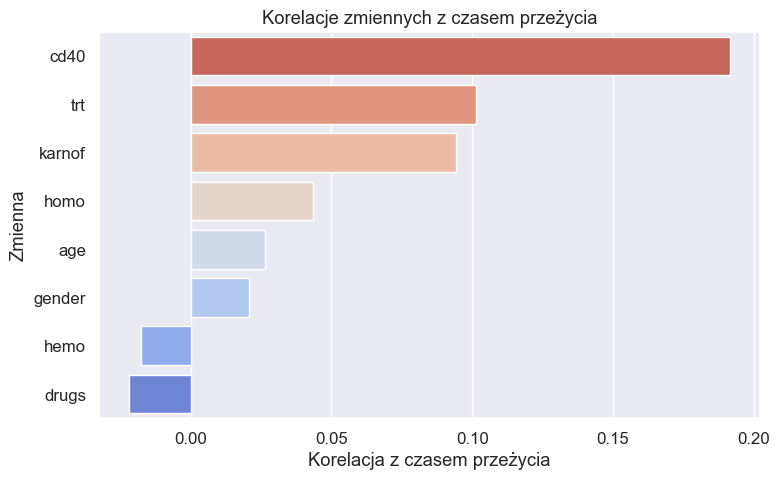

In [10]:
###  Zobrazowanie korelacji między zmiennymi a czasem przeżycia
selected_cols = ["trt", "hemo", "cd40", "age", "karnof", "gender", "homo", "drugs", "time"]
numeric_cols = df[selected_cols].select_dtypes(include=[np.number]).columns.tolist()
correlations = df[numeric_cols].corr()['time'].sort_values(ascending=False)
correlations = correlations.drop('time')

print("\nKorelacje wybranych zmiennych z czasem przeżycia:")
correlations_df = correlations.reset_index()
correlations_df.columns = ['Zmienna', 'Korelacja z czasem przeżycia']
display(correlations_df.style.background_gradient(cmap='coolwarm', subset=['Korelacja z czasem przeżycia']).format({'Korelacja z czasem przeżycia': '{:.5f}'}))

### Zobrazowanie korelacji jako wykres słupkowy i zapis do pliku PNG
plt.figure(figsize=(8, 5))
sns.barplot(
    data=correlations_df,
    y='Zmienna',
    x='Korelacja z czasem przeżycia',
    palette='coolwarm_r', # w sns "_r" oznacza odwrócenie kierunku palety kol
    orient='h'
)
plt.title('Korelacje zmiennych z czasem przeżycia')
plt.xlabel('Korelacja z czasem przeżycia')
plt.ylabel('Zmienna')
plt.tight_layout()
plt.savefig('correlations_with_time.png', dpi=150)
plt.show()


Krzywa K-M z przedziałami ufności i tabelą osób narażonych na ryzyko


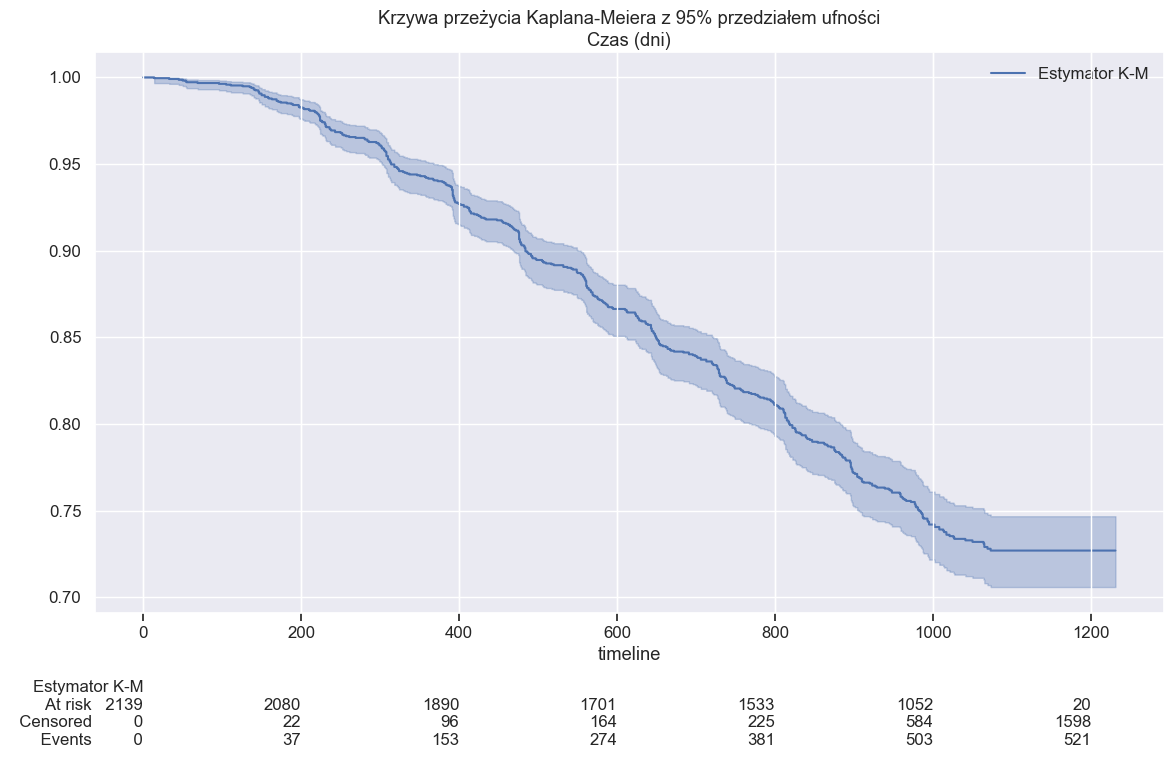

In [11]:
### Krzywa Kaplana-Meiera z przedziałami ufności i tabelą osób narażonych na ryzyko
print("\nKrzywa K-M z przedziałami ufności i tabelą osób narażonych na ryzyko")
plt.figure(figsize=(12, 8))
ax = plt.subplot(111)

# Wywołanie krzywej Kaplana-Meiera
kmf = KaplanMeierFitter()
kmf.fit(df['time'], df['cid'], label='Estymator K-M', alpha=0.05, )
kmf.plot(ax=ax, ci_show=True, ci_alpha=0.3)
# Dodanie tabeli osób narażonych na ryzyko
add_at_risk_counts(kmf, ax=ax)

plt.title('Krzywa przeżycia Kaplana-Meiera z 95% przedziałem ufności')
plt.xlabel('Czas (dni)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
### Tabela przeżycia Kaplana-Meiera
print("\nTabela przeżycia Kaplana-Meiera")

### Tworzenie tabeli z wynikami
kmf_table = pd.DataFrame(kmf.survival_function_)
kmf_table.columns = ['Przeżycie']
kmf_table['Dolny przedz. ufności'] = kmf.confidence_interval_['Estymator K-M_lower_0.95']
kmf_table['Górny przedz. ufności'] = kmf.confidence_interval_['Estymator K-M_upper_0.95']
kmf_table['Skumulowana funkcja hazardu'] = -(np.log(kmf.survival_function_.values))
kmf_table['Skumulowana funkcja hazardu'][0] = 0 ### korekta wizualna
kmf_table['Zdarzenia'] = kmf.event_table['observed']
kmf_table['Cenzorowane'] = kmf.event_table['censored']
kmf_table['Narażeni na ryzyko'] = kmf.event_table['at_risk']


print("Fragment tabeli przeżycia (pierwsze 10 wierszy):")
display(kmf_table.head(10))
print("\nFragment tabeli przeżycia (ostatnie 10 wierszy):")
display(kmf_table.tail(10))

### Zapisanie tabeli do pliku excelowego
kmf_table.to_excel('kmf_table.xlsx', index=True)



Tabela przeżycia Kaplana-Meiera
Fragment tabeli przeżycia (pierwsze 10 wierszy):


,Przeżycie,Dolny przedz. ufności,Górny przedz. ufności,Skumulowana funkcja hazardu,Zdarzenia,Cenzorowane,Narażeni na ryzyko
timeline,,,,,,,
0.0,1.000000,1.000000,1.000000,0.000000,0,0,2139
14.0,0.999532,0.996686,0.999934,0.000468,1,0,2139
33.0,0.999065,0.996267,0.999766,0.000935,1,0,2138
45.0,0.998597,0.995658,0.999547,0.001404,1,0,2137
50.0,0.998130,0.995025,0.999298,0.001872,1,0,2136
54.0,0.997662,0.994393,0.999026,0.002340,1,0,2135
55.0,0.997195,0.993767,0.998739,0.002809,1,0,2134
62.0,0.997195,0.993767,0.998739,0.002809,0,1,2133
69.0,0.996727,0.993147,0.998438,0.003278,1,0,2132



Fragment tabeli przeżycia (ostatnie 10 wierszy):


,Przeżycie,Dolny przedz. ufności,Górny przedz. ufności,Skumulowana funkcja hazardu,Zdarzenia,Cenzorowane,Narażeni na ryzyko
timeline,,,,,,,
1203.0,0.726948,0.705909,0.746762,0.3189,0,3,19
1206.0,0.726948,0.705909,0.746762,0.3189,0,1,16
1209.0,0.726948,0.705909,0.746762,0.3189,0,2,15
1211.0,0.726948,0.705909,0.746762,0.3189,0,1,13
1214.0,0.726948,0.705909,0.746762,0.3189,0,2,12
1217.0,0.726948,0.705909,0.746762,0.3189,0,1,10
1223.0,0.726948,0.705909,0.746762,0.3189,0,1,9
1224.0,0.726948,0.705909,0.746762,0.3189,0,4,8
1230.0,0.726948,0.705909,0.746762,0.3189,0,1,4



Porównanie krzywych przeżycia według grupy leczenia

Wyniki testu log-rank między grupami leczenia:
Test log-rank: p-value = 1.1860553904066413e-10

Wyniki testu Wilcoxona między grupami leczenia:
Test Wilcoxon: p-value = 3.3999467719771347e-12


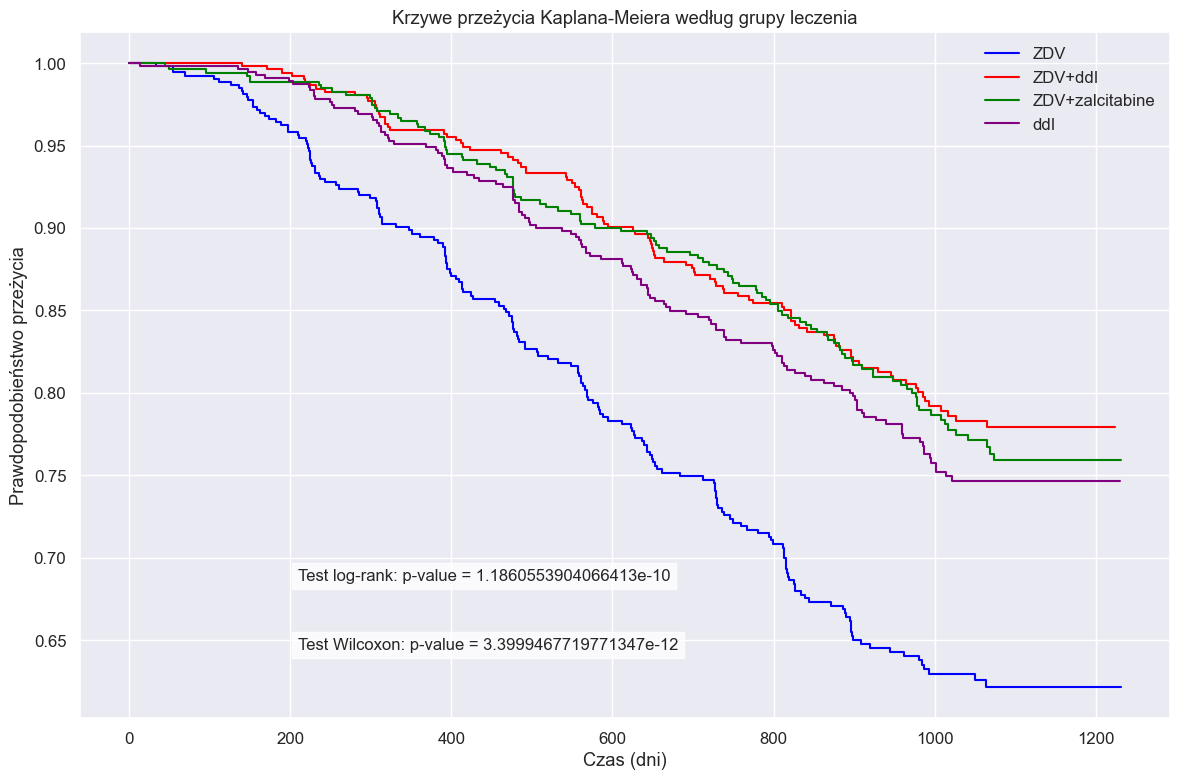


Porównania parami między grupami leczenia:


,Grupa 1,Grupa 2,p-value
0,ZDV,ZDV+ddI,6.073732e-09
1,ZDV,ZDV+zalcitabine,8.055119e-08
2,ZDV,ddI,3.749631e-06
4,ZDV+ddI,ddI,1.856294e-01
5,ZDV+zalcitabine,ddI,3.980275e-01
3,ZDV+ddI,ZDV+zalcitabine,6.362565e-01


In [13]:
### Porównanie krzywych przeżycia według grupy leczenia (trt)
print("\nPorównanie krzywych przeżycia według grupy leczenia")

plt.figure(figsize=(12, 8))
ax = plt.subplot(111)

unique_treatments = np.sort(df['trt'].unique())

### Podział na grupy leczenia
colors = ['blue', 'red', 'green', 'purple']
treatment_labels = {
    0: 'ZDV',            # Zidovudine monotherapy
    1: 'ZDV+ddI',        # Zidovudine + didanosine
    2: 'ZDV+zalcitabine', # Zidovudine + zalcitabine
    3: 'ddI'             # didanosine monotherapy
}

# Przygotowanie danych do testów parami
group_data = {}
for treatment in sorted(unique_treatments):
    mask = df['trt'] == treatment
    kmf_treat = KaplanMeierFitter()
    
    label = treatment_labels.get(treatment, f'Leczenie {treatment}')
    kmf_treat.fit(df['time'][mask], df['cid'][mask], label=label)
    
    color = colors[treatment % len(colors)]
    kmf_treat.plot(ax=ax, ci_show=False, color=color)
    
    # Zapisujemy dane dla testów parami
    group_data[treatment] = {
        'durations': df['time'][mask],
        'events': df['cid'][mask]
    }

### Test log-rank do porównania grup
print("\nWyniki testu log-rank między grupami leczenia:")
results_log_rank = multivariate_logrank_test(df['time'], df['trt'], df['cid'])
results_log_rank_text = f"Test log-rank: p-value = {results_log_rank.p_value}"
print(results_log_rank_text)

### Test wilcoxona do porównania grup
print("\nWyniki testu Wilcoxona między grupami leczenia:")
results_wilcoxon_rank = multivariate_logrank_test(df['time'], df['trt'], df['cid'], weightings="wilcoxon")
results_wilcoxon_text = f"Test Wilcoxon: p-value = {results_wilcoxon_rank.p_value}"
print(results_wilcoxon_text)

plt.text(0.2, 0.2, results_log_rank_text, transform=ax.transAxes, fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.8))
plt.text(0.2, 0.1, results_wilcoxon_text, transform=ax.transAxes, fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.title('Krzywe przeżycia Kaplana-Meiera według grupy leczenia')
plt.xlabel('Czas (dni)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Porównania parami między grupami leczenia
print("\nPorównania parami między grupami leczenia:")
results = {}
for i, group1 in enumerate(sorted(unique_treatments)[:-1]):
    for group2 in sorted(unique_treatments)[i+1:]:
        test = logrank_test(
            group_data[group1]['durations'],
            group_data[group2]['durations'],
            group_data[group1]['events'],
            group_data[group2]['events']
        )
        results[(treatment_labels[group1], treatment_labels[group2])] = test.p_value

# Wyświetlenie wyników
comparison_results = pd.DataFrame(columns=['Grupa 1', 'Grupa 2', 'p-value'])
for i, ((group1, group2), p) in enumerate(results.items()):
    comparison_results.loc[i] = [group1, group2, p]
display(comparison_results.sort_values(by='p-value', ascending=True))

comparison_results.sort_values(by='p-value', ascending=True).to_excel('comparison_results.xlsx', index=False)


Porównanie krzywych przeżycia według grupy leczenia

Wyniki testu log-rank między grupami leczenia:
Test log-rank: p-value = 1.1860553904066413e-10

Wyniki testu Wilcoxona między grupami leczenia:
Test Wilcoxon: p-value = 3.3999467719771347e-12


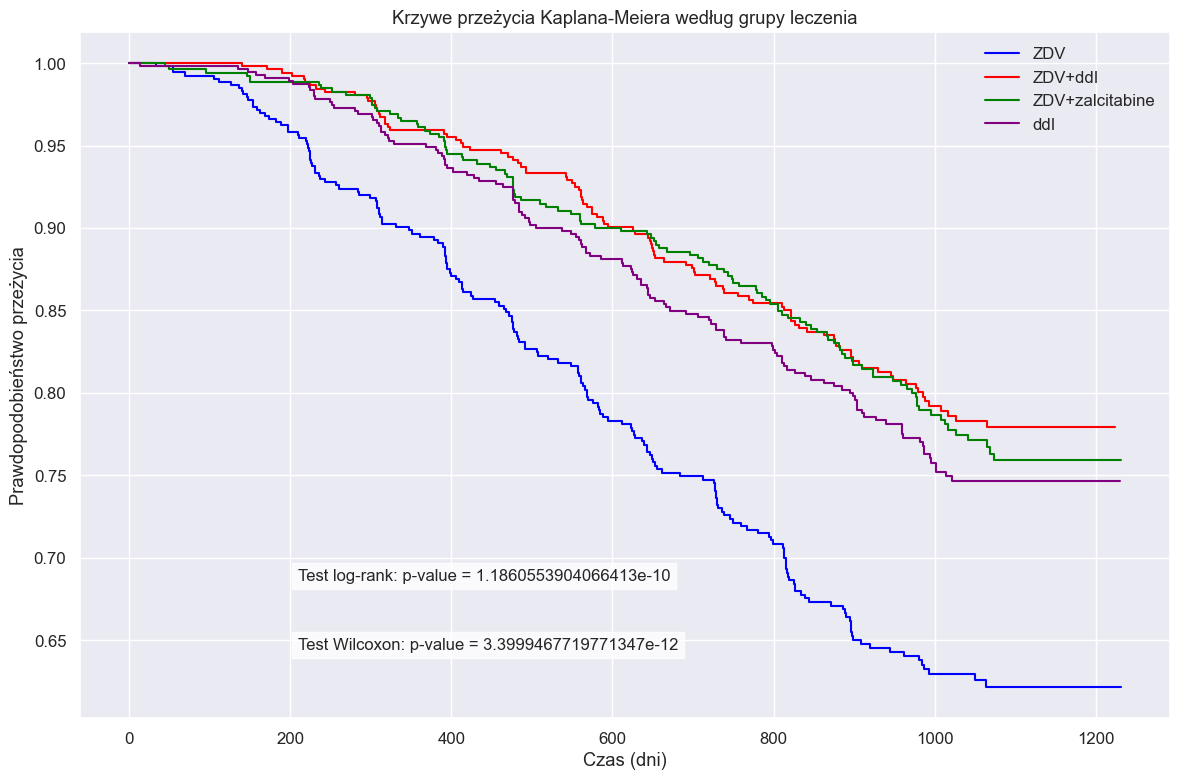


Porównania parami między grupami leczenia:


,Grupa 1,Grupa 2,p-value
0,ZDV,ZDV+ddI,0.00000
1,ZDV,ZDV+zalcitabine,0.00000
2,ZDV,ddI,0.00000
4,ZDV+ddI,ddI,0.18563
5,ZDV+zalcitabine,ddI,0.39803
3,ZDV+ddI,ZDV+zalcitabine,0.63626


In [14]:
### Porównanie krzywych przeżycia według grupy leczenia (trt)
print("\nPorównanie krzywych przeżycia według grupy leczenia")

plt.figure(figsize=(12, 8))
ax = plt.subplot(111)

unique_treatments = np.sort(df['trt'].unique())

### Podział na grupy leczenia
colors = ['blue', 'red', 'green', 'purple']
treatment_labels = {
    0: 'ZDV',            # Zidovudine monotherapy
    1: 'ZDV+ddI',        # Zidovudine + didanosine
    2: 'ZDV+zalcitabine', # Zidovudine + zalcitabine
    3: 'ddI'             # didanosine monotherapy
}

# Przygotowanie danych do testów parami
group_data = {}
for treatment in sorted(unique_treatments):
    mask = df['trt'] == treatment
    kmf_treat = KaplanMeierFitter()
    
    label = treatment_labels.get(treatment, f'Leczenie {treatment}')
    kmf_treat.fit(df['time'][mask], df['cid'][mask], label=label)
    
    color = colors[treatment % len(colors)]
    kmf_treat.plot(ax=ax, ci_show=False, color=color)
    
    # Zapisujemy dane dla testów parami
    group_data[treatment] = {
        'durations': df['time'][mask],
        'events': df['cid'][mask]
    }

### Test log-rank do porównania grup
print("\nWyniki testu log-rank między grupami leczenia:")
results_log_rank = multivariate_logrank_test(df['time'], df['trt'], df['cid'])
results_log_rank_text = f"Test log-rank: p-value = {results_log_rank.p_value}"
print(results_log_rank_text)

### Test wilcoxona do porównania grup
print("\nWyniki testu Wilcoxona między grupami leczenia:")
results_wilcoxon_rank = multivariate_logrank_test(df['time'], df['trt'], df['cid'], weightings="wilcoxon")
results_wilcoxon_text = f"Test Wilcoxon: p-value = {results_wilcoxon_rank.p_value}"
print(results_wilcoxon_text)

plt.text(0.2, 0.2, results_log_rank_text, transform=ax.transAxes, fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.8))
plt.text(0.2, 0.1, results_wilcoxon_text, transform=ax.transAxes, fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.title('Krzywe przeżycia Kaplana-Meiera według grupy leczenia')
plt.xlabel('Czas (dni)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Porównania parami między grupami leczenia
print("\nPorównania parami między grupami leczenia:")
results = {}
for i, group1 in enumerate(sorted(unique_treatments)[:-1]):
    for group2 in sorted(unique_treatments)[i+1:]:
        test = logrank_test(
            group_data[group1]['durations'],
            group_data[group2]['durations'],
            group_data[group1]['events'],
            group_data[group2]['events']
        )
        results[(treatment_labels[group1], treatment_labels[group2])] = test.p_value

# Wyświetlenie wyników
comparison_results = pd.DataFrame(columns=['Grupa 1', 'Grupa 2', 'p-value'])
for i, ((group1, group2), p) in enumerate(results.items()):
    comparison_results.loc[i] = [group1, group2, np.round(p,5)]
display(comparison_results.sort_values(by='p-value', ascending=True))

comparison_results.sort_values(by='p-value', ascending=True).to_excel('comparison_results.xlsx', index=False)


Porównanie krzywych przeżycia według płci

Wyniki testu log-rank między grupami płci:
Test log-rank: p-value = 0.08565037548947144

Wyniki testu Wilcoxona między grupami płci:
Test Wilcoxon: p-value = 0.08906236313318536


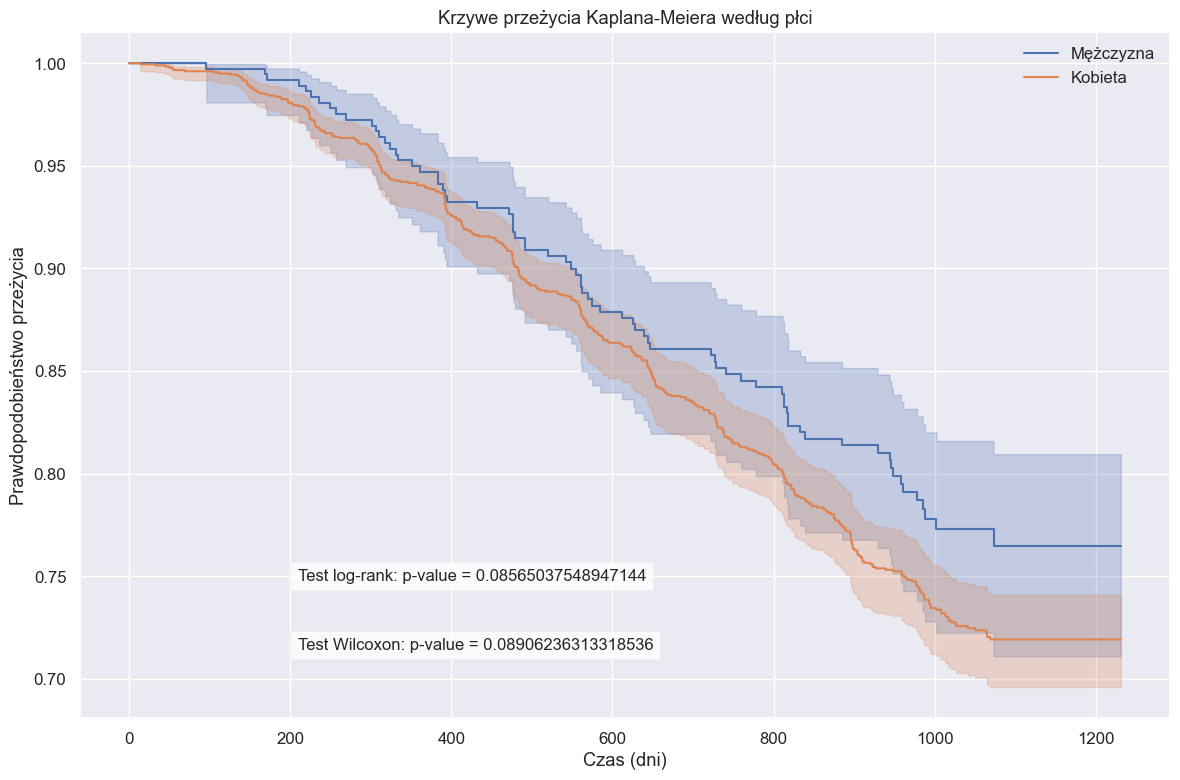

In [15]:

### Analiza dla innej zmiennej kategorycznej (np. 'gender')
print("\nPorównanie krzywych przeżycia według płci")

plt.figure(figsize=(12, 8))
ax = plt.subplot(111)

gender_labels = {0: 'Mężczyzna', 1: 'Kobieta'}

for gender in sorted(df['gender'].unique()):
    mask = df['gender'] == gender
    kmf_gender = KaplanMeierFitter()
    
    label = gender_labels.get(gender, f'Płeć {gender}')
    kmf_gender.fit(df['time'][mask], df['cid'][mask], label=label)
    
    kmf_gender.plot(ax=ax, ci_show=True)


# Test log-rank dla płci
print("\nWyniki testu log-rank między grupami płci:")
results_log_rank = multivariate_logrank_test(df['time'], df['gender'], df['cid'])
results_log_rank_text = f"Test log-rank: p-value = {results_log_rank.p_value}"
print(results_log_rank_text)

# Test wilcoxona do porównania grup płci
print("\nWyniki testu Wilcoxona między grupami płci:")
results_wilcoxon_rank = multivariate_logrank_test(df['time'], df['gender'], df['cid'], weightings="wilcoxon")
results_wilcoxon_text = f"Test Wilcoxon: p-value = {results_wilcoxon_rank.p_value}"
print(results_wilcoxon_text)


plt.text(0.2, 0.2, results_log_rank_text, transform=ax.transAxes, fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.8))
plt.text(0.2, 0.1, results_wilcoxon_text, transform=ax.transAxes, fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.8))


plt.title('Krzywe przeżycia Kaplana-Meiera według płci')
plt.xlabel('Czas (dni)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Porównanie grup z korektą dla wielokrotnych porównań


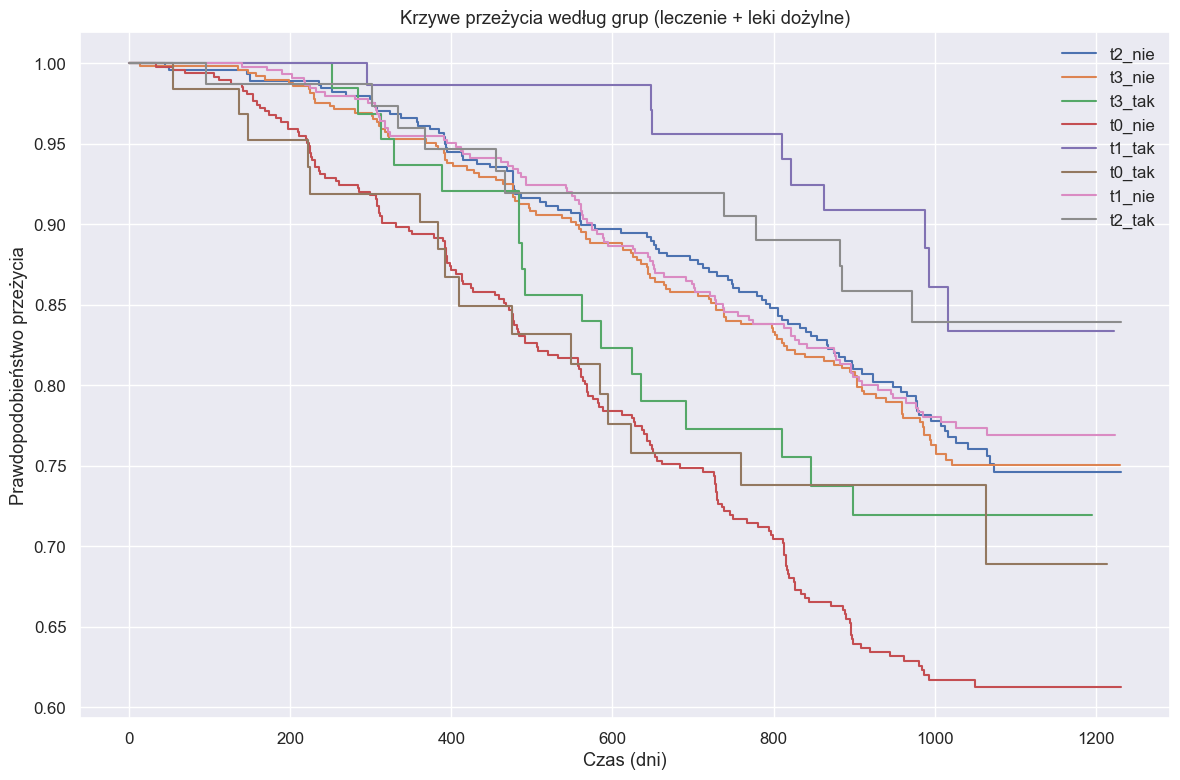


Testy parami log-rank, wraz z p-value


,Grupa 1,Grupa 2,p-value
2,t2_nie,t0_nie,0.00000
8,t3_nie,t0_nie,0.00000
20,t0_nie,t1_nie,0.00000
18,t0_nie,t1_tak,0.00011
21,t0_nie,t2_tak,0.00050
22,t1_tak,t0_tak,0.01927
14,t3_tak,t1_tak,0.02638
9,t3_nie,t1_tak,0.05604
26,t0_tak,t2_tak,0.05621
3,t2_nie,t1_tak,0.07264


In [16]:
#Porównanie z wieloma zmiennymi warstwującymi i korektami
print("\nPorównanie grup z korektą dla wielokrotnych porównań")

# Tworzenie przykładowej zmiennej grupującej (np. kombinacja leczenie +  i stosowanie leków dożylnie)
df['grupa'] = 't' + df['trt'].astype(str) + '_' + df['drugs'].apply(lambda x: 'tak' if x == 1 else 'nie')
groups = df['grupa'].unique()

plt.figure(figsize=(12, 8))
ax = plt.subplot(111)

group_data = {}
for group in groups:
    mask = df['grupa'] == group
    if sum(mask) < 5:  # Pomijamy grupy z niewielką liczbą obserwacji
        continue
        
    kmf_group = KaplanMeierFitter()
    kmf_group.fit(df['time'][mask], df['cid'][mask], label=f"{group}")
    kmf_group.plot(ax=ax, ci_show=False)
    
    # Przechowujemy dane do testów parami
    group_data[group] = {
        'durations': df['time'][mask],
        'events': df['cid'][mask]
    }

plt.title('Krzywe przeżycia według grup (leczenie + leki dożylne)')
plt.xlabel('Czas (dni)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Testy parami log-rank z korektą dla wielokrotnych porównań
print("\nTesty parami log-rank, wraz z p-value")
results = {}
p_values = []

# Porównania parami
for i, group1 in enumerate(group_data.keys()):
    for group2 in list(group_data.keys())[i+1:]:
        if len(group_data[group1]['durations']) < 5 or len(group_data[group2]['durations']) < 5:
            continue
            
        test = logrank_test(
            group_data[group1]['durations'], 
            group_data[group2]['durations'],
            group_data[group1]['events'], 
            group_data[group2]['events']
        )
        results[(group1, group2)] = np.round(test.p_value,5)
        p_values.append(test.p_value)


# Wyświetlenie wyników
comparison_results = pd.DataFrame(columns=['Grupa 1', 'Grupa 2', 'p-value'])
for i, ((group1, group2), p) in enumerate(results.items()):
    comparison_results.loc[i] = [group1, group2, p]
display(comparison_results.sort_values(by='p-value', ascending=True))


comparison_results.sort_values(by='p-value', ascending=True).to_excel('comparison_results.xlsx', index=False)

In [17]:
### Własna funckcja do tworzenia tablicy życia
def create_life_table(durations, events, intervals=None):

    ### Tworzenie przedziałów automatycznie
    if intervals is None:
        max_duration = max(durations)
        intervals = np.linspace(0, max_duration, 11)[1:]
    
    ### Stworzenie początkowej tablicy życia
    # floor i ceil dodane dla czytelności
    life_table = pd.DataFrame({
        'Początek przedziału': [0] + list(np.ceil(intervals)[:-1]),
        'Koniec przedziału': list(np.floor(intervals)),
        'Środek przedziału (t_jm)': np.zeros(len(intervals)),
        'Szerokość przedziału (b_j)': np.zeros(len(intervals)),
        'Narażeni na ryzyko (n_j)': np.zeros(len(intervals)),
        'Zdarzenia (d_j)': np.zeros(len(intervals)),
        'Cenzorowane (m_j)': np.zeros(len(intervals)),
        'Hazard (h_j)': np.zeros(len(intervals)),
        'Prawdop. zdarzenia (q_j)': np.zeros(len(intervals)),
        'Prawdop. przeżycia przedziału (p_j)': np.zeros(len(intervals)),
        'Przeżycie skumulowane (S(t))': np.zeros(len(intervals)),
    })
    
    ### Obliczanie podstawowych wartości dla przedziałów
    for i, (start, end) in enumerate(zip(life_table['Początek przedziału'], life_table['Koniec przedziału'])):
        # Szerokość przedziału
        life_table.loc[i, 'Szerokość przedziału (b_j)'] = end - start
        # Środek przedziału
        life_table.loc[i, 'Środek przedziału (t_jm)'] = (start + end) / 2
        
        # Zdarzenia i cenzorowania w przedziale
        if i == 0:
            in_interval = (durations <= end)
        else:
            in_interval = (durations > start) & (durations <= end)
        
        life_table.loc[i, 'Zdarzenia (d_j)'] = sum(in_interval & (events == 1))
        life_table.loc[i, 'Cenzorowane (m_j)'] = sum(in_interval & (events == 0))
        
        # Narażeni na ryzyko na początku przedziału
        N_j = sum(durations >= start)
        m_j = life_table.loc[i, 'Cenzorowane (m_j)']
        
        # Efektywnie narażeni na ryzyko (skorygowani o cenzurowanie)
        life_table.loc[i, 'Narażeni na ryzyko (n_j)'] = N_j - m_j / 2
    
    ### Obliczanie funkcji hazardu i przeżycia
    surv_prob = 1.0
    for i in range(len(life_table)):
        n_j = life_table.loc[i, 'Narażeni na ryzyko (n_j)']
        d_j = life_table.loc[i, 'Zdarzenia (d_j)']
        b_j = life_table.loc[i, 'Szerokość przedziału (b_j)']
        
        if n_j > 0:
            # Prawdopodobieństwo zajścia zdarzenia w przedziale
            q_j = d_j / n_j
            life_table.loc[i, 'Prawdop. zdarzenia (q_j)'] = q_j
            
            # Prawdopodobieństwo przeżycia przedziału
            p_j = 1 - q_j
            life_table.loc[i, 'Prawdop. przeżycia przedziału (p_j)'] = p_j
            
            # Funkcja hazardu
            hazard = d_j / (b_j * n_j)
            life_table.loc[i, 'Hazard (h_j)'] = hazard
        else:
            life_table.loc[i, 'Prawdop. zdarzenia (q_j)'] = 0
            life_table.loc[i, 'Prawdop. przeżycia przedziału (p_j)'] = 1
            life_table.loc[i, 'Hazard (h_j)'] = 0
        
        # Skumulowana funkcja przeżycia
        surv_prob *= life_table.loc[i, 'Prawdop. przeżycia przedziału (p_j)']
        life_table.loc[i, 'Przeżycie skumulowane (S(t))'] = surv_prob
    
    return life_table

### Tworzenie tablicy życia z automatycznymi przedziałami
life_table_auto = create_life_table(df['time'], df['cid'])
print("\nTablica życia z automatycznymi przedziałami:")
display(life_table_auto)

life_table_auto.to_excel('life_table.xlsx', index=True)


Tablica życia z automatycznymi przedziałami:


,Początek przedziału,Koniec przedziału,Środek przedziału (t_jm),Szerokość przedziału (b_j),Narażeni na ryzyko (n_j),Zdarzenia (d_j),Cenzorowane (m_j),Hazard (h_j),Prawdop. zdarzenia (q_j),Prawdop. przeżycia przedziału (p_j),Przeżycie skumulowane (S(t))
0,0.0,123.0,61.5,123.0,2138.0,10.0,2.0,0.000038,0.004677,0.995323,0.995323
1,124.0,246.0,185.0,122.0,2110.5,57.0,33.0,0.000221,0.027008,0.972992,0.968441
2,247.0,369.0,308.0,122.0,2013.5,58.0,47.0,0.000236,0.028806,0.971194,0.940545
3,370.0,492.0,431.0,122.0,1908.5,89.0,47.0,0.000382,0.046633,0.953367,0.896684
4,493.0,615.0,554.0,122.0,1776.5,62.0,37.0,0.000286,0.034900,0.965100,0.865390
5,616.0,738.0,677.0,122.0,1676.0,76.0,36.0,0.000372,0.045346,0.954654,0.826148
6,739.0,861.0,800.0,122.0,1560.5,65.0,43.0,0.000341,0.041653,0.958347,0.791736
7,862.0,984.0,923.0,122.0,1350.0,69.0,240.0,0.000419,0.051111,0.948889,0.751269
8,985.0,1107.0,1046.0,122.0,807.0,28.0,706.0,0.000284,0.034696,0.965304,0.725203
9,1108.0,1231.0,1169.5,123.0,212.0,0.0,420.0,0.000000,0.000000,1.000000,0.725203


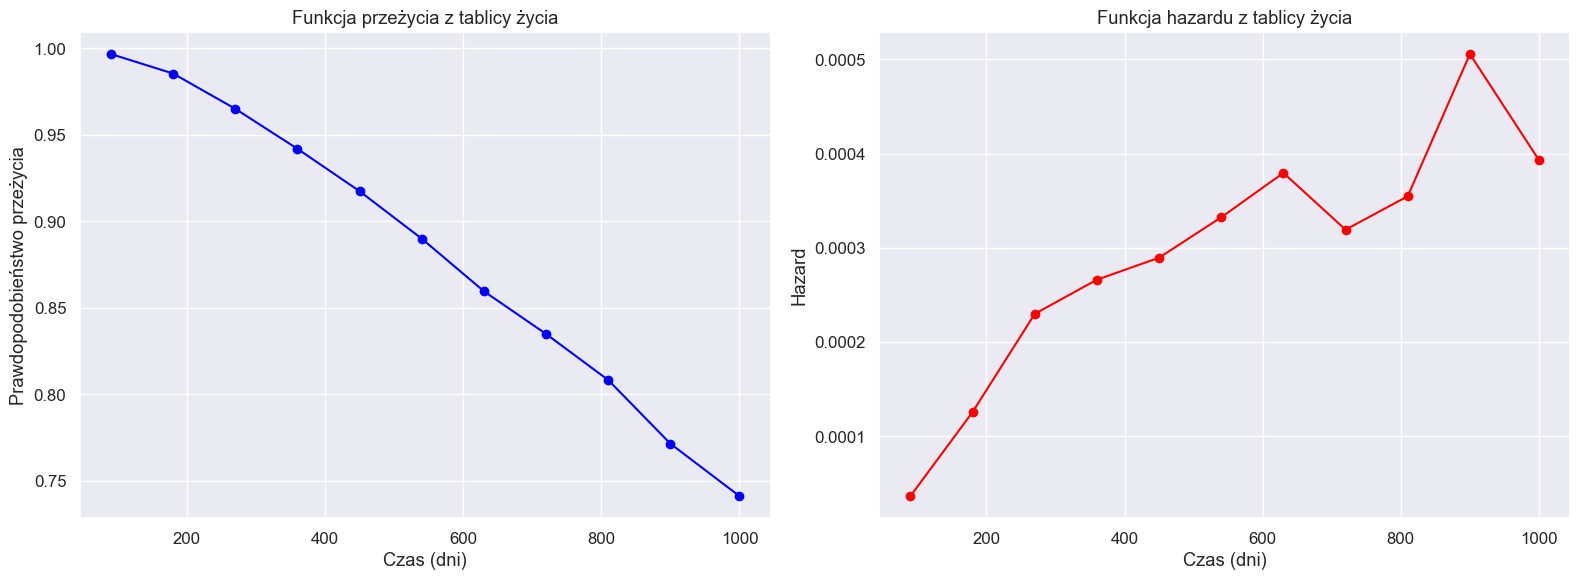

In [18]:
### Wykres funkcji przeżycia i hazardu z tablicy życia
plt.figure(figsize=(16, 6))

custom_intervals = [90, 180, 270, 360, 450, 540, 630, 720, 810, 900, 1000]
life_table_custom = create_life_table(df['time'], df['cid'], intervals=custom_intervals)

plt.subplot(1, 2, 1)
plt.plot(life_table_custom['Koniec przedziału'], life_table_custom['Przeżycie skumulowane (S(t))'], '-o', color='blue')
plt.title('Funkcja przeżycia z tablicy życia')
plt.xlabel('Czas (dni)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.grid(True)

plt.subplot(1, 2, 2)
# plt.bar(life_table_custom['Koniec przedziału'] - (np.diff(custom_intervals, prepend=0)/2), 
#         life_table_custom['Hazard (h_j)'], 
#         width=np.diff(custom_intervals, prepend=0), 
#         color='red',
#         edgecolor='black', alpha=0.7)
plt.plot(life_table_custom['Koniec przedziału'], 
        life_table_custom['Hazard (h_j)'], '-o', color='red')
plt.title('Funkcja hazardu z tablicy życia')
plt.xlabel('Czas (dni)')
plt.ylabel('Hazard')
plt.grid(True)

plt.tight_layout()
plt.show()


Logarytm funkcji przeżycia


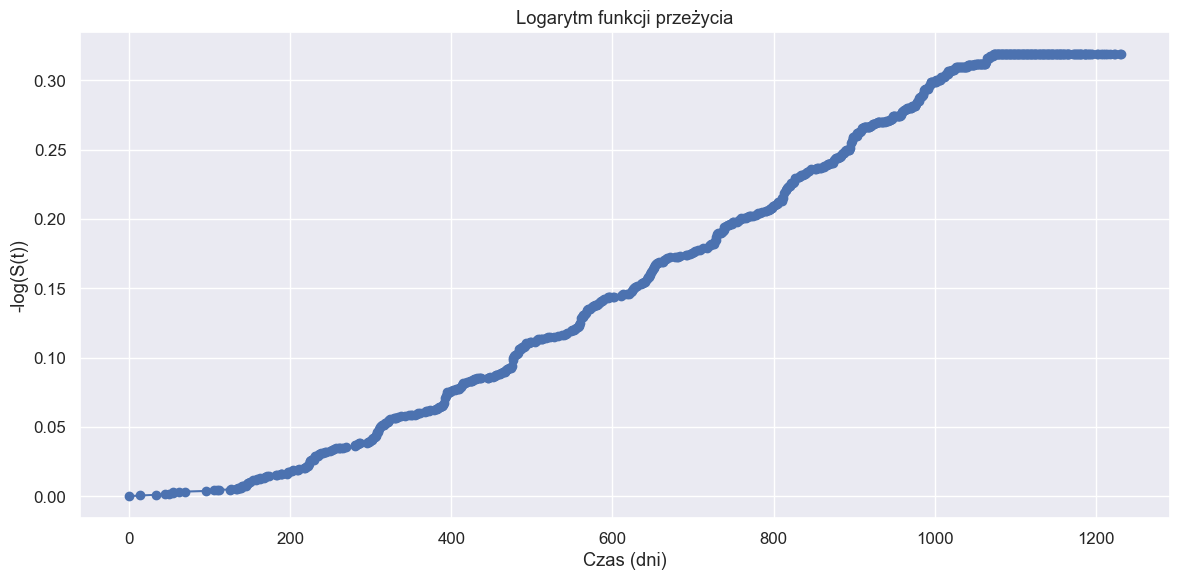

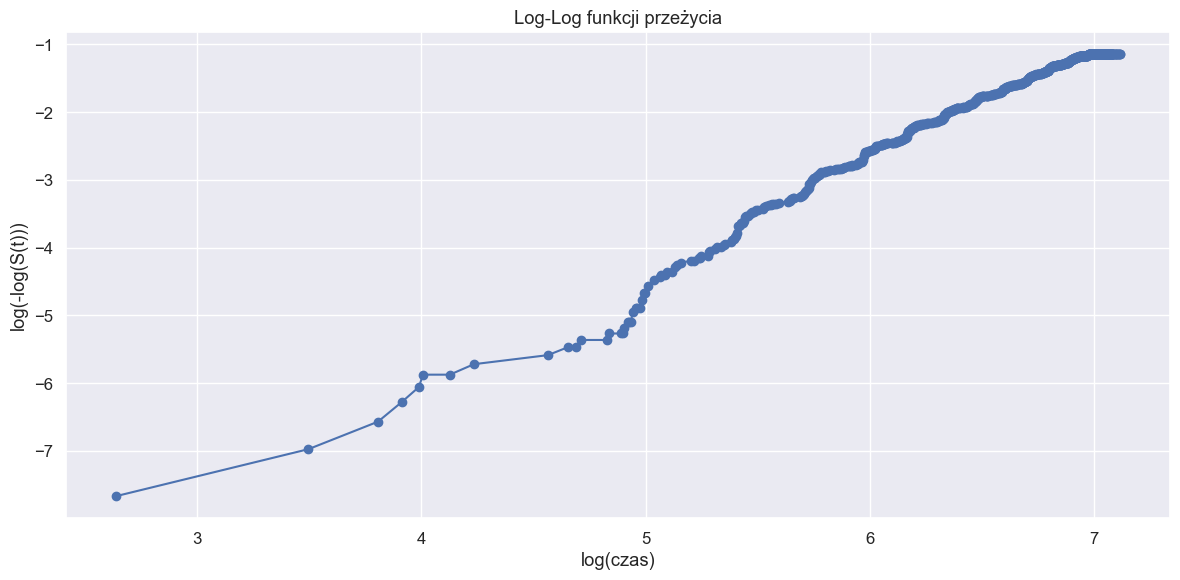

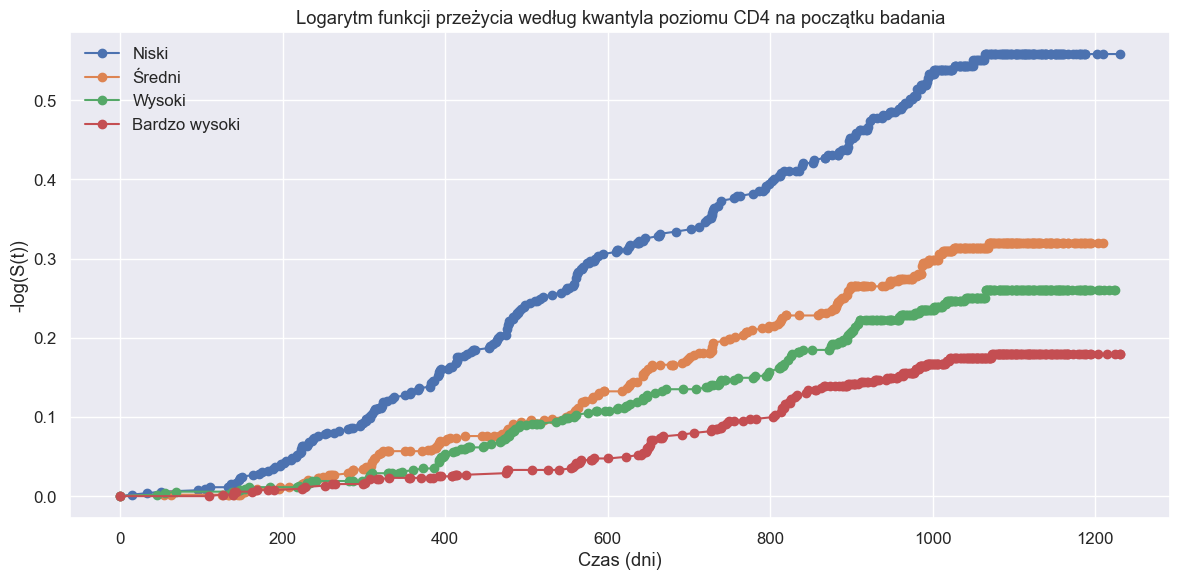

In [19]:
### Logarytm funkcji przeżycia
print("\nLogarytm funkcji przeżycia")

plt.figure(figsize=(12, 6))

### kategoryzacja przez pd.qcut

cd40_cat_labels = {0: 'Niski', 1: 'Średni', 2: 'Wysoki', 3: 'Bardzo wysoki'}

df['cd40_cat'] = pd.qcut(df['cd40'], q=4, labels=False)


### Estymacja Kaplana-Meiera
kmf = KaplanMeierFitter()
kmf.fit(df['time'], df['cid'])

### Funkcja przeżycia w skali logarytmicznej
log_surv = -np.log(kmf.survival_function_)
log_surv.columns = ['Log Survival']

plt.plot(log_surv.index, log_surv['Log Survival'], 'o-')
plt.title('Logarytm funkcji przeżycia')
plt.xlabel('Czas (dni)')
plt.ylabel('-log(S(t))')
plt.grid(True)
plt.tight_layout()
plt.show()

# Logarytm-logarytm funkcji przeżycia (log(-log(S(t))))
plt.figure(figsize=(12, 6))
loglog_surv = np.log(-np.log(kmf.survival_function_))
loglog_surv.columns = ['Log-Log Survival']

plt.plot(np.log(loglog_surv.index), loglog_surv['Log-Log Survival'], 'o-')
plt.title('Log-Log funkcji przeżycia')
plt.xlabel('log(czas)')
plt.ylabel('log(-log(S(t)))')
plt.grid(True)
plt.tight_layout()
plt.show()

# Logarytm funkcji przeżycia dla różnych grup leczenia
plt.figure(figsize=(12, 6))

for cd40_value in sorted(df['cd40_cat'].unique()):
    mask = df['cd40_cat'] == cd40_value
    kmf_cd40 = KaplanMeierFitter()
    kmf_cd40.fit(df['time'][mask], df['cid'][mask], label=f'{cd40_cat_labels[cd40_value]}')
    
    log_surv_cd40 = -np.log(kmf_cd40.survival_function_)
    plt.plot(log_surv_cd40.index, log_surv_cd40.iloc[:, 0], 'o-', label=f'{cd40_cat_labels[cd40_value]}')

plt.title('Logarytm funkcji przeżycia według kwantyla poziomu CD4 na początku badania')
plt.xlabel('Czas (dni)')
plt.ylabel('-log(S(t))')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Wygładzanie kernelowe funkcji hazardu


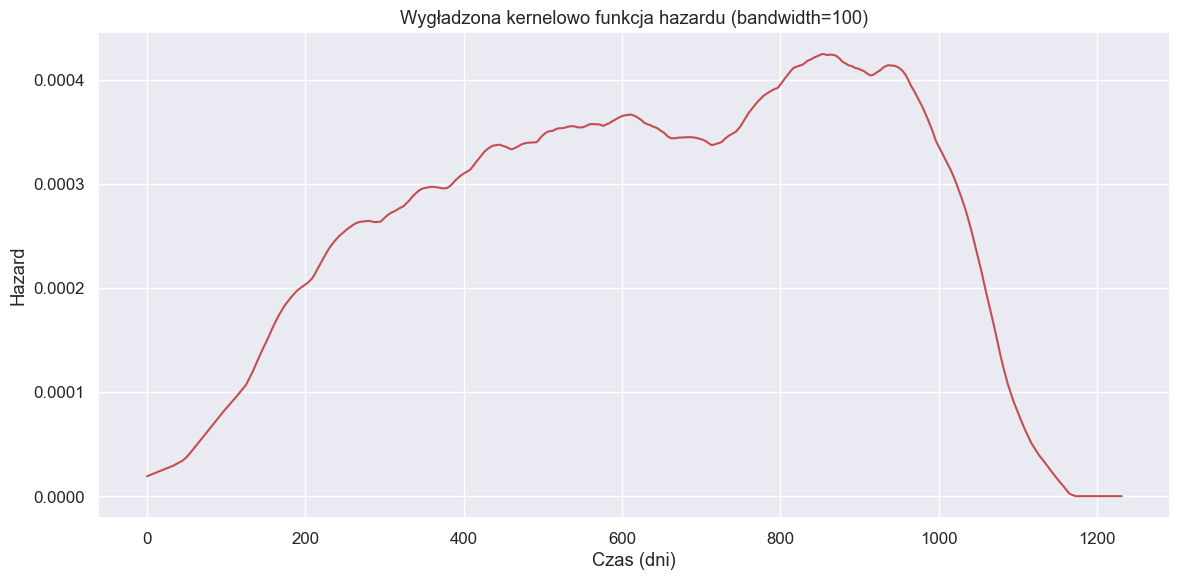

In [20]:
### Wygładzanie kernelowe funkcji hazardu
print("\nWygładzanie kernelowe funkcji hazardu")

### W nowszych wersjach lifelines nie potrzebujemy importować kernel_smoother osobno
### Funkcja smoothed_hazard_ jest dostępna bezpośrednio w NelsonAalenFitter

### Estymator Nelsona-Aalena dla skumulowanej funkcji hazardu
naf = NelsonAalenFitter()
naf.fit(df['time'], df['cid'])

### Funkcja hazardu wygładzona kernelowo
hazard_x = naf.smoothed_hazard_(bandwidth=100)

plt.figure(figsize=(12, 6))
plt.plot(hazard_x, 'r-', label='Wygładzona funkcja hazardu')
plt.title('Wygładzona kernelowo funkcja hazardu (bandwidth=100)')
plt.xlabel('Czas (dni)')
plt.ylabel('Hazard')
plt.grid(True)
plt.tight_layout()
plt.show()

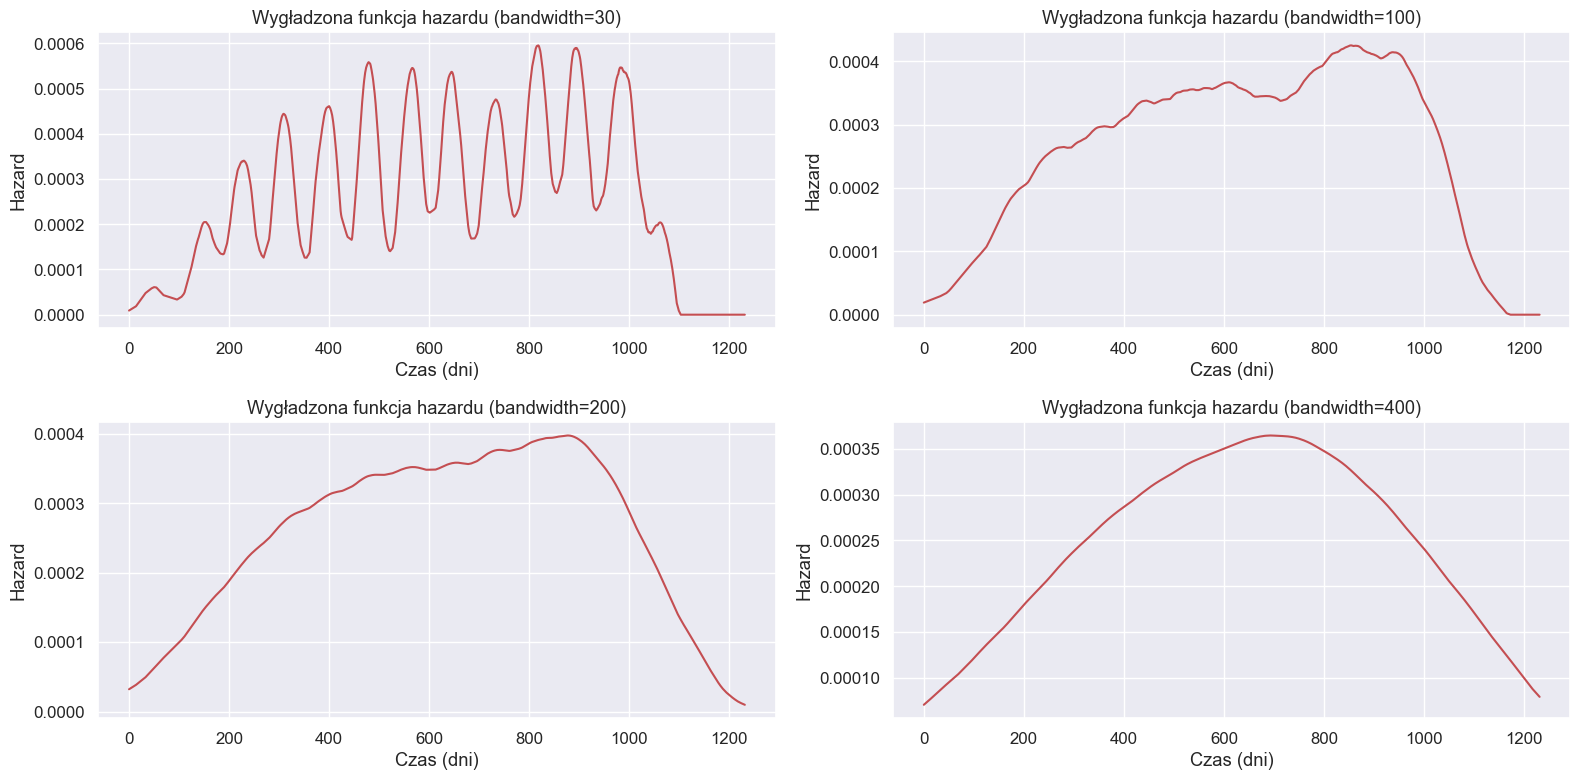

In [21]:
### porównanie funkcji hazardu dla różnych wartości bandwidth
plt.figure(figsize=(16, 8)) 
for i, bandwidth in enumerate([30, 100, 200, 400]):
    plt.subplot(2, 2, i+1)
    hazard_x = naf.smoothed_hazard_(bandwidth=bandwidth)
    plt.plot(hazard_x, 'r-')
    plt.title(f'Wygładzona funkcja hazardu (bandwidth={bandwidth})')
    plt.xlabel('Czas (dni)')
    plt.ylabel('Hazard')
    plt.grid(True)

plt.tight_layout()
plt.show()

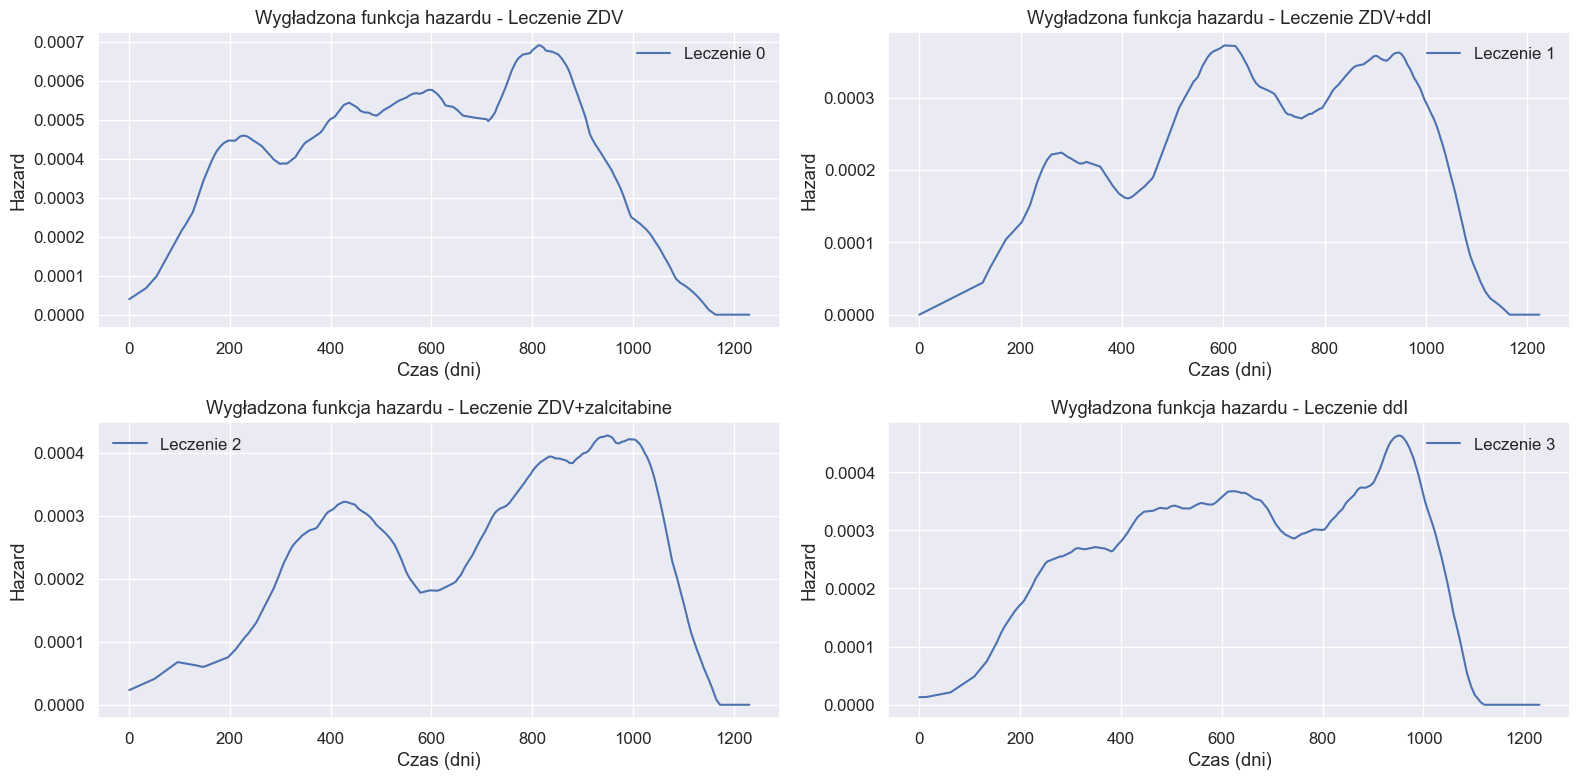

In [22]:
### Wygładzanie kernelowe dla różnych grup leczenia
plt.figure(figsize=(16, 8))

treatment_labels = {
    0: 'ZDV',            # Zidovudine monotherapy
    1: 'ZDV+ddI',        # Zidovudine + didanosine
    2: 'ZDV+zalcitabine', # Zidovudine + zalcitabine
    3: 'ddI'             # didanosine monotherapy
}


for i, trt_value in enumerate(sorted(df['trt'].unique())):
        
    plt.subplot(2, 2, i+1)
    
    mask = df['trt'] == trt_value
    naf_trt = NelsonAalenFitter()
    naf_trt.fit(df['time'][mask], df['cid'][mask])
    
    hazard_x = naf_trt.smoothed_hazard_(bandwidth=100)
        
    plt.plot(hazard_x, '-', label=f'Leczenie {trt_value}')
    
    plt.title(f'Wygładzona funkcja hazardu - Leczenie {treatment_labels[i]}')
    plt.xlabel('Czas (dni)')
    plt.ylabel('Hazard')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


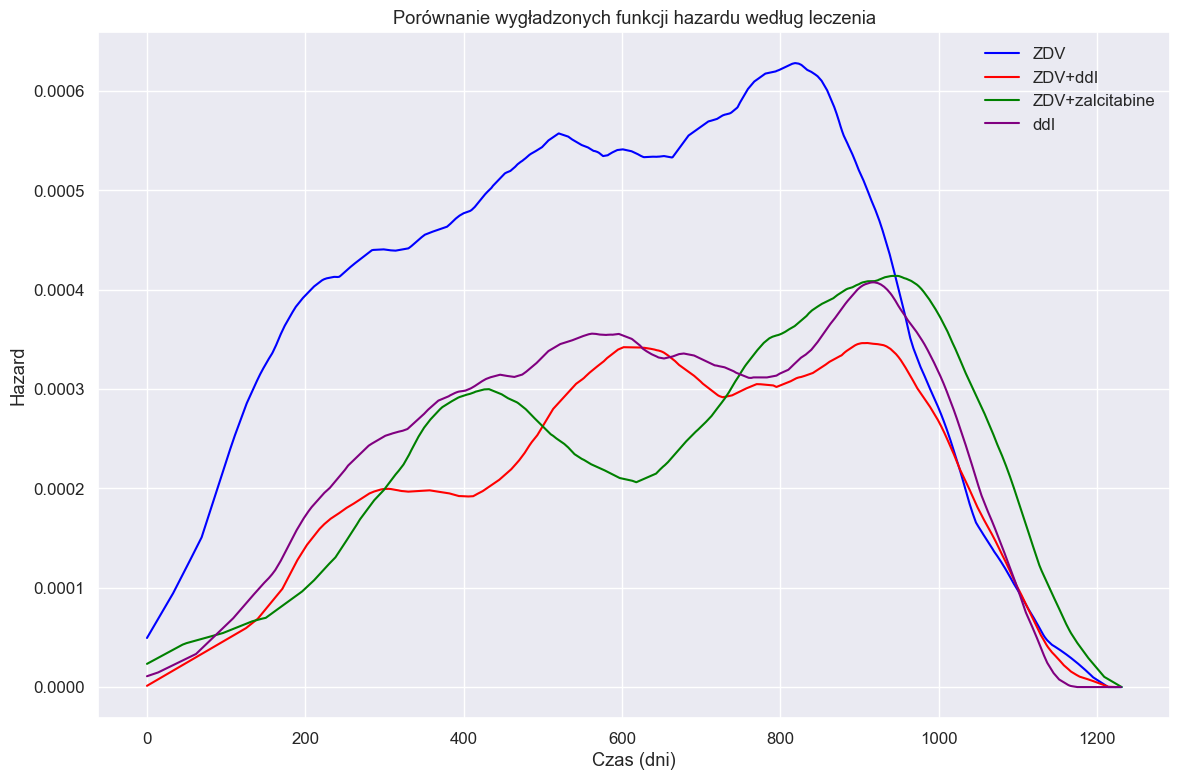

In [23]:
### Porównanie funkcji hazardu między grupami na jednym wykresie
plt.figure(figsize=(12, 8))

treatment_labels = {
    0: 'ZDV',            # Zidovudine monotherapy
    1: 'ZDV+ddI',        # Zidovudine + didanosine
    2: 'ZDV+zalcitabine', # Zidovudine + zalcitabine
    3: 'ddI'             # didanosine monotherapy
}


colors = ['blue', 'red', 'green', 'purple']
for i, trt_value in enumerate(sorted(df['trt'].unique())):
    mask = df['trt'] == trt_value
    
    if sum(mask) < 10:  # Pomijamy grupy z małą liczbą obserwacji
        continue
        
    naf_trt = NelsonAalenFitter()
    naf_trt.fit(df['time'][mask], df['cid'][mask])
    
    hazard_x = naf_trt.smoothed_hazard_(bandwidth=150)
        
    plt.plot(hazard_x, color=colors[i % len(colors)], label=f'{treatment_labels[i]}')

plt.title('Porównanie wygładzonych funkcji hazardu według leczenia')
plt.xlabel('Czas (dni)')
plt.ylabel('Hazard')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()